In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [142]:
data = pd.read_csv("./data/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


#### 분석목적: 학력, 교육연수, 혼인상태, 직업정보가 있는 연봉데이터셋을 이용해 연봉 예측하기


연봉이 5만달러 이상인지 아닌지

* age: 나이
* workclass: 고용형태
* education: 학력
* education-num: 교육연수
* marital-status: 혼인상태
* occupation: 직업
* relationship: 가족관계
* race: 인종
* sex: 성별
* capital-gain: 자산증가
* capital-loss: 자산감소
* hours-per-week: 주당 노동 시간
* native-country: 본국
* class: 연봉구분 - target(분석대상)

In [4]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

In [5]:
data['education'].value_counts()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

In [13]:
data['workclass']

0              Private
1              Private
2            Local-gov
3              Private
4                  NaN
             ...      
48837          Private
48838          Private
48839          Private
48840          Private
48841     Self-emp-inc
Name: workclass, Length: 48842, dtype: object


In [14]:
data['workclass'].value_counts()

workclass
Private             33906
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

In [19]:
data['workclass'].mode()[0]

' Private'

In [21]:
data['occupation'].value_counts()

occupation
Prof-specialty       6172
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

In [25]:
data['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Nicaragua                        49
Greece                           49
Peru                             46
Ecuador      

In [24]:
data.isna().sum()/len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

# 데이터 전처리

In [26]:
data['workclass'] = data['workclass'].fillna(data['workclass'].mode()[0])
data['occupation'] = data['occupation'].fillna(data['occupation'].mode()[0])
data['native-country'] = data['native-country'].fillna(data['native-country'].mode()[0])

In [27]:
data.isna().sum()

age               0
workclass         0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
class             0
dtype: int64

In [28]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


In [29]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      48842 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   capital-gain    48842 non-null  int64 
 10  capital-loss    48842 non-null  int64 
 11  hours-per-week  48842 non-null  int64 
 12  native-country  48842 non-null  object
 13  class           48842 non-null  object
dtypes: int64(5), object(9)
memory usage: 5.2+ MB


<Axes: >

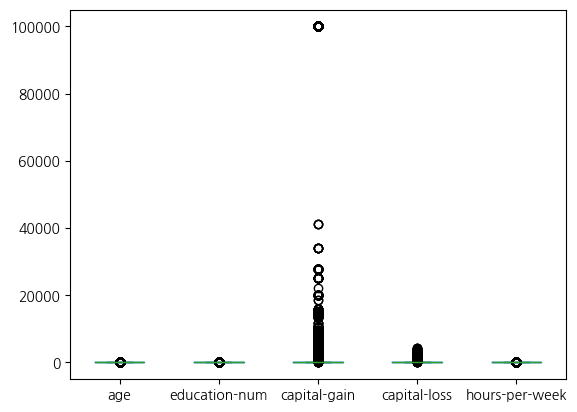

In [30]:
data.plot(kind='box')

In [53]:
data['capital-gain'].value_counts() / len(data['capital-gain']) * 100

capital-gain
0        91.738668
15024     1.050326
7688      0.839441
7298      0.745260
99999     0.499570
           ...    
6612      0.002047
1111      0.002047
22040     0.002047
1639      0.002047
2387      0.002047
Name: count, Length: 123, dtype: float64

In [54]:
data['capital-loss'].value_counts() / len(data['capital-loss']) * 100

capital-loss
0       95.327792
1902     0.622415
1977     0.517997
1887     0.477048
2415     0.147414
          ...    
1539     0.002047
2489     0.002047
2080     0.002047
155      0.002047
2201     0.002047
Name: count, Length: 99, dtype: float64

In [37]:
data[['capital-gain', 'capital-loss']].describe()

,capital-gain,capital-loss
count,48842.000000,48842.000000
mean,1079.067626,87.502314
std,7452.019058,403.004552
min,0.000000,0.000000
25%,0.000000,0.000000
50%,0.000000,0.000000
75%,0.000000,0.000000
max,99999.000000,4356.000000


In [40]:
data[['capital-gain']].describe()

,capital-gain
count,48842.000000
mean,1079.067626
std,7452.019058
min,0.000000
25%,0.000000
50%,0.000000
75%,0.000000
max,99999.000000


In [41]:
data[['capital-gain']].median()

capital-gain    0.0
dtype: float64

In [33]:
cg_desc = data['capital-gain'].describe()

In [34]:
cg_desc

count    48842.000000
mean      1079.067626
std       7452.019058
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64

In [56]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [57]:
data['age'].value_counts()

age
36    1348
35    1337
33    1335
23    1329
31    1325
      ... 
88       6
85       5
87       3
89       2
86       1
Name: count, Length: 74, dtype: int64

<Axes: ylabel='Frequency'>

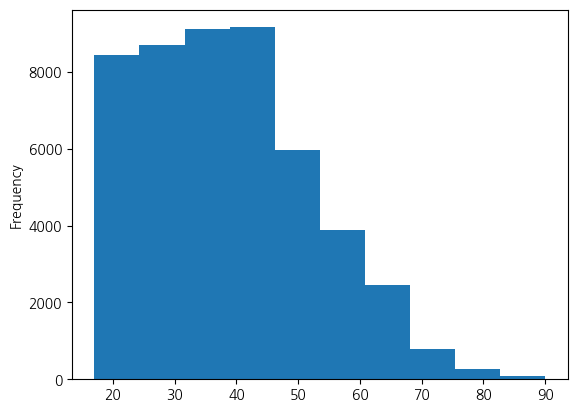

In [66]:
data['age'].plot(kind="hist")

In [67]:
data['workclass'].value_counts()

workclass
Private             36705
Self-emp-not-inc     3862
Local-gov            3136
State-gov            1981
Self-emp-inc         1695
Federal-gov          1432
Without-pay            21
Never-worked           10
Name: count, dtype: int64

<Axes: xlabel='workclass'>

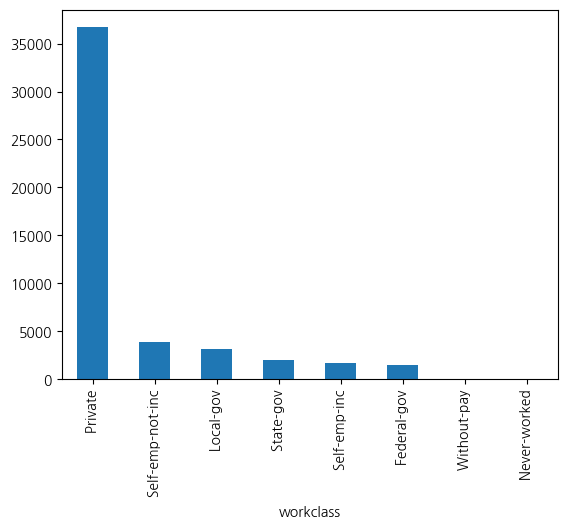

In [73]:
data['workclass'].value_counts().plot(kind="bar")

In [74]:
data['education'].value_counts()

education
HS-grad         15784
Some-college    10878
Bachelors        8025
Masters          2657
Assoc-voc        2061
11th             1812
Assoc-acdm       1601
10th             1389
7th-8th           955
Prof-school       834
9th               756
12th              657
Doctorate         594
5th-6th           509
1st-4th           247
Preschool          83
Name: count, dtype: int64

<Axes: ylabel='count'>

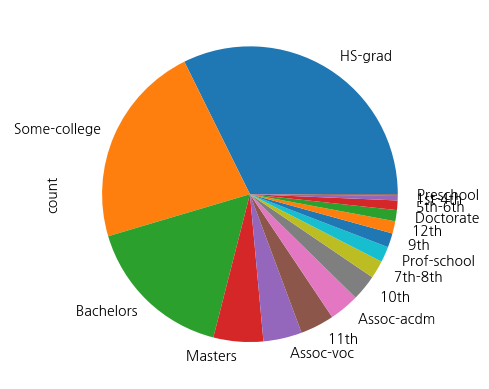

In [76]:
data['education'].value_counts().plot(kind="pie")

In [77]:
data['education-num'].value_counts()

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

In [79]:
data['marital-status'].value_counts()

marital-status
Married-civ-spouse       22379
Never-married            16117
Divorced                  6633
Separated                 1530
Widowed                   1518
Married-spouse-absent      628
Married-AF-spouse           37
Name: count, dtype: int64

In [80]:
data['occupation'].value_counts()

occupation
Prof-specialty       8981
Craft-repair         6112
Exec-managerial      6086
Adm-clerical         5611
Sales                5504
Other-service        4923
Machine-op-inspct    3022
Transport-moving     2355
Handlers-cleaners    2072
Farming-fishing      1490
Tech-support         1446
Protective-serv       983
Priv-house-serv       242
Armed-Forces           15
Name: count, dtype: int64

<Axes: xlabel='occupation'>

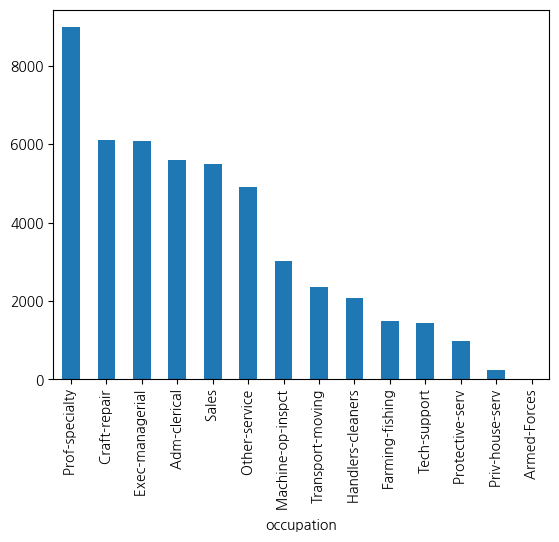

In [82]:
data['occupation'].value_counts().plot(kind="bar")

In [83]:
data['relationship'].value_counts()

relationship
Husband           19716
Not-in-family     12583
Own-child          7581
Unmarried          5125
Wife               2331
Other-relative     1506
Name: count, dtype: int64

In [84]:
data['race'].value_counts()

race
White                 41762
Black                  4685
Asian-Pac-Islander     1519
Amer-Indian-Eskimo      470
Other                   406
Name: count, dtype: int64

In [85]:
data['sex'].value_counts()

sex
Male      32650
Female    16192
Name: count, dtype: int64

In [89]:
data['capital-gain'].value_counts() / len(data) * 100

capital-gain
0        91.738668
15024     1.050326
7688      0.839441
7298      0.745260
99999     0.499570
           ...    
6612      0.002047
1111      0.002047
22040     0.002047
1639      0.002047
2387      0.002047
Name: count, Length: 123, dtype: float64

In [90]:
data['capital-loss'].value_counts() / len(data) * 100

capital-loss
0       95.327792
1902     0.622415
1977     0.517997
1887     0.477048
2415     0.147414
          ...    
1539     0.002047
2489     0.002047
2080     0.002047
155      0.002047
2201     0.002047
Name: count, Length: 99, dtype: float64

In [91]:
data['hours-per-week'].value_counts()

hours-per-week
40    22803
50     4246
45     2717
60     2177
35     1937
      ...  
79        1
94        1
87        1
69        1
82        1
Name: count, Length: 96, dtype: int64

In [95]:
data['native-country'].value_counts() / len(data) * 100

native-country
United-States                 91.497072
Mexico                         1.947095
Philippines                    0.603988
Germany                        0.421768
Puerto-Rico                    0.376725
Canada                         0.372630
El-Salvador                    0.317350
India                          0.309160
Cuba                           0.282544
England                        0.260022
China                          0.249785
South                          0.235453
Jamaica                        0.217026
Italy                          0.214979
Dominican-Republic             0.210884
Japan                          0.188362
Guatemala                      0.180173
Poland                         0.178125
Vietnam                        0.176078
Columbia                       0.174031
Haiti                          0.153556
Portugal                       0.137177
Taiwan                         0.133082
Iran                           0.120798
Nicaragua                

In [93]:
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [94]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'capital-gain',
       'capital-loss', 'hours-per-week', 'native-country', 'class'],
      dtype='object')

In [148]:
data = data.drop(['capital-gain','capital-loss'], axis = 1)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,20,United-States,<=50K


In [149]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'hours-per-week',
       'native-country', 'class'],
      dtype='object')

In [103]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             48842 non-null  int64 
 1   workclass       48842 non-null  object
 2   education       48842 non-null  object
 3   education-num   48842 non-null  int64 
 4   marital-status  48842 non-null  object
 5   occupation      48842 non-null  object
 6   relationship    48842 non-null  object
 7   race            48842 non-null  object
 8   sex             48842 non-null  object
 9   hours-per-week  48842 non-null  int64 
 10  native-country  48842 non-null  object
 11  class           48842 non-null  object
dtypes: int64(3), object(9)
memory usage: 4.5+ MB


In [105]:
data['education-num'].describe()

count    48842.000000
mean        10.078089
std          2.570973
min          1.000000
25%          9.000000
50%         10.000000
75%         12.000000
max         16.000000
Name: education-num, dtype: float64

In [106]:
data['education-num'].mean()

np.float64(10.078088530363212)

In [109]:
data['age'].describe()

count    48842.000000
mean        38.643585
std         13.710510
min         17.000000
25%         28.000000
50%         37.000000
75%         48.000000
max         90.000000
Name: age, dtype: float64

In [110]:
data['age'] = pd.cut(data['age'], 
      bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 90],
      labels = ['under10s', '10s', '20s', '30s', '40s', '50s', '60s', '70s', '80s'],
                    right=False)

In [116]:
data['class']

0         <=50K
1         <=50K
2          >50K
3          >50K
4         <=50K
          ...  
48837     <=50K
48838      >50K
48839     <=50K
48840     <=50K
48841      >50K
Name: class, Length: 48842, dtype: object

In [114]:
data['class'].describe()

count      48842
unique         2
top        <=50K
freq       37155
Name: class, dtype: object

In [150]:
data.describe()

,age,education-num,hours-per-week
count,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,40.422382
std,13.710510,2.570973,12.391444
min,17.000000,1.000000,1.000000
25%,28.000000,9.000000,40.000000
50%,37.000000,10.000000,40.000000
75%,48.000000,12.000000,45.000000
max,90.000000,16.000000,99.000000


In [127]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'hours-per-week',
       'native-country', 'class'],
      dtype='object')

In [ ]:
num_col = data['age', 'education-num', 'hours-per-week']

In [ ]:
cat_col = data['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex',  'native-country', 'class']

In [ ]:
data = data.drop('native-country', axis = 1)

In [158]:
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,hours-per-week,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,40,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,50,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,40,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,40,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,30,<=50K
...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,38,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,40,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,40,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,20,<=50K


<Axes: ylabel='count'>

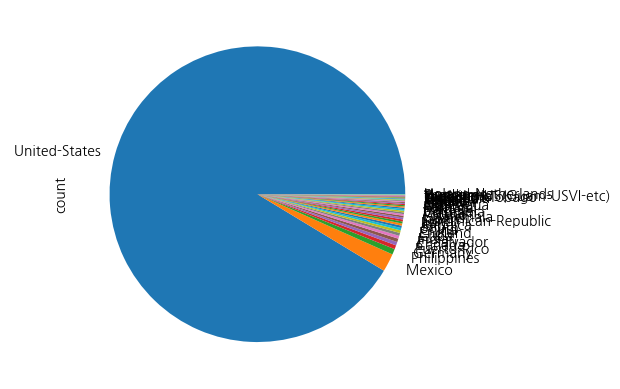

In [155]:
data['native-country'].value_counts().plot(kind='pie')

In [153]:
data['native-country'].value_counts()

native-country
United-States                 43832
Mexico                          951
Philippines                     295
Germany                         206
Puerto-Rico                     184
Canada                          182
El-Salvador                     155
India                           151
Cuba                            138
England                         127
China                           122
South                           115
Jamaica                         106
Italy                           105
Dominican-Republic              103
Japan                            92
Guatemala                        88
Poland                           87
Vietnam                          86
Columbia                         85
Haiti                            75
Portugal                         67
Taiwan                           65
Iran                             59
Nicaragua                        49
Greece                           49
Peru                             46
Ecuador      

In [161]:
data['relationship'].value_counts() / len(data) * 100

relationship
Husband           40.366897
Not-in-family     25.762663
Own-child         15.521477
Unmarried         10.493018
Wife               4.772532
Other-relative     3.083412
Name: count, dtype: float64

In [144]:
data['education-num'].value_counts()

education-num
9     15784
10    10878
13     8025
14     2657
11     2061
7      1812
12     1601
6      1389
4       955
15      834
5       756
8       657
16      594
3       509
2       247
1        83
Name: count, dtype: int64

In [159]:
data.columns

Index(['age', 'workclass', 'education', 'education-num', 'marital-status',
       'occupation', 'relationship', 'race', 'sex', 'hours-per-week', 'class'],
      dtype='object')

In [162]:
data = pd.get_dummies(data, columns=['age', 'sex', 'relationship', 'race'], drop_first=True)
data

,workclass,education,education-num,marital-status,occupation,hours-per-week,class,age_18,age_19,age_20,...,sex_ Male,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,Private,11th,7,Never-married,Machine-op-inspct,40,<=50K,False,False,False,...,True,False,False,True,False,False,False,True,False,False
1,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,50,<=50K,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,40,>50K,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,40,>50K,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,NaN,Some-college,10,Never-married,NaN,30,<=50K,True,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,38,<=50K,False,False,False,...,False,False,False,False,False,True,False,False,False,True
48838,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,40,>50K,False,False,False,...,True,False,False,False,False,False,False,False,False,True
48839,Private,HS-grad,9,Widowed,Adm-clerical,40,<=50K,False,False,False,...,False,False,False,False,True,False,False,False,False,True
48840,Private,HS-grad,9,Never-married,Adm-clerical,20,<=50K,False,False,False,...,True,False,False,True,False,False,False,False,False,True


# 독립변수(문제, X), 종속변수(답, y)

In [163]:
X = data.drop('class', axis=1)
y = data['class']

In [164]:
X

,workclass,education,education-num,marital-status,occupation,hours-per-week,age_18,age_19,age_20,age_21,...,sex_ Male,relationship_ Not-in-family,relationship_ Other-relative,relationship_ Own-child,relationship_ Unmarried,relationship_ Wife,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White
0,Private,11th,7,Never-married,Machine-op-inspct,40,False,False,False,False,...,True,False,False,True,False,False,False,True,False,False
1,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,50,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
2,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,40,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
3,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,40,False,False,False,False,...,True,False,False,False,False,False,False,True,False,False
4,NaN,Some-college,10,Never-married,NaN,30,True,False,False,False,...,False,False,False,True,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,38,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
48838,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,40,False,False,False,False,...,True,False,False,False,False,False,False,False,False,True
48839,Private,HS-grad,9,Widowed,Adm-clerical,40,False,False,False,False,...,False,False,False,False,True,False,False,False,False,True
48840,Private,HS-grad,9,Never-married,Adm-clerical,20,False,False,False,False,...,True,False,False,True,False,False,False,False,False,True


In [165]:
y

0         <=50K
1         <=50K
2          >50K
3          >50K
4         <=50K
          ...  
48837     <=50K
48838      >50K
48839     <=50K
48840     <=50K
48841      >50K
Name: class, Length: 48842, dtype: object

# 데이터 훈련

In [123]:
from sklearn.model_selection import train_test_split

In [166]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)

In [125]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [167]:
dtc = DecisionTreeClassifier(random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

ValueError: could not convert string to float: ' Private'

# 풀이

In [170]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import koreanize_matplotlib
import seaborn as sns

In [171]:
data = pd.read_csv("./data/salary2.csv")
data.head()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K


In [172]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week
count,48842.000000,48842.000000,48842.000000,48842.000000,48842.000000
mean,38.643585,10.078089,1079.067626,87.502314,40.422382
std,13.710510,2.570973,7452.019058,403.004552,12.391444
min,17.000000,1.000000,0.000000,0.000000,1.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000
75%,48.000000,12.000000,0.000000,0.000000,45.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000


# 결측값 탐색

In [173]:
data.isna().sum()

age                  0
workclass         2799
education            0
education-num        0
marital-status       0
occupation        2809
relationship         0
race                 0
sex                  0
capital-gain         0
capital-loss         0
hours-per-week       0
native-country     857
class                0
dtype: int64

삭제했을 때 편향이 일어나지 않는지, 확인해보기

In [176]:
data.isna().sum() / len(data) * 100

age               0.000000
workclass         5.730724
education         0.000000
education-num     0.000000
marital-status    0.000000
occupation        5.751198
relationship      0.000000
race              0.000000
sex               0.000000
capital-gain      0.000000
capital-loss      0.000000
hours-per-week    0.000000
native-country    1.754637
class             0.000000
dtype: float64

In [178]:
data['class'].value_counts()

class
<=50K    37155
>50K     11687
Name: count, dtype: int64

In [181]:
data[data['workclass'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [182]:
data[data['occupation'].isna()]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
4,18,NaN,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States,<=50K
6,29,NaN,HS-grad,9,Never-married,NaN,Unmarried,Black,Male,0,0,40,United-States,<=50K
13,58,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,<=50K
22,72,NaN,7th-8th,4,Divorced,NaN,Not-in-family,White,Female,0,0,6,United-States,<=50K
35,65,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K
48812,30,NaN,Bachelors,13,Never-married,NaN,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K
48820,71,NaN,Doctorate,16,Married-civ-spouse,NaN,Husband,White,Male,0,0,10,United-States,>50K
48822,41,NaN,HS-grad,9,Separated,NaN,Not-in-family,Black,Female,0,0,32,United-States,<=50K


In [187]:
data[(data['occupation'].isna() & data['workclass'].isna() & (data['class'] == ' >50K'))]

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
89,41,NaN,Masters,14,Married-civ-spouse,NaN,Wife,White,Female,7688,0,10,United-States,>50K
182,28,NaN,HS-grad,9,Married-civ-spouse,NaN,Own-child,White,Female,0,0,38,United-States,>50K
274,53,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,35,United-States,>50K
505,38,NaN,HS-grad,9,Married-civ-spouse,NaN,Wife,White,Female,0,1887,10,United-States,>50K
781,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,5178,0,40,United-States,>50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48278,60,NaN,Some-college,10,Married-civ-spouse,NaN,Husband,White,Male,0,0,12,United-States,>50K
48279,52,NaN,12th,8,Married-civ-spouse,NaN,Wife,Black,Female,0,0,40,United-States,>50K
48297,62,NaN,HS-grad,9,Married-civ-spouse,NaN,Husband,White,Male,0,0,40,United-States,>50K
48811,35,NaN,Bachelors,13,Married-civ-spouse,NaN,Wife,White,Female,0,0,55,United-States,>50K


In [185]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [188]:
265 / 11687 * 100

2.267476683494481

In [189]:
data['class'].unique()

array([' <=50K', ' >50K'], dtype=object)

In [191]:
data.dropna()

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
5,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48837,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
48838,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
48839,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
48840,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [192]:
45222 / len(data) * 100

92.58834609557348

# 결측값의 비율이 약 5%이고 삭제시 데이터 분포에 편향을 주지 않으므로 삭제

In [194]:
data = data.dropna()
data = data.reset_index(drop=True)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


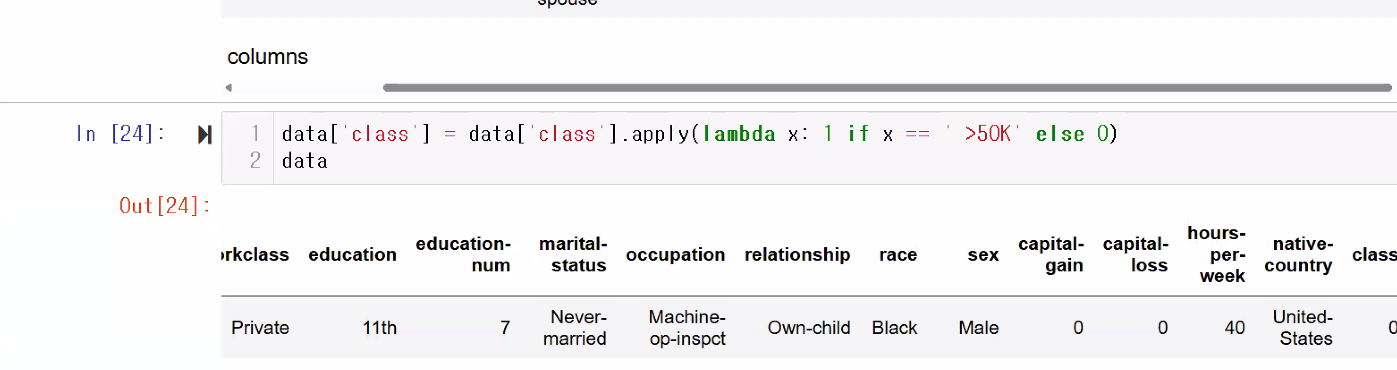

연봉 컬럼을 1,0 으로 구분짓기

In [195]:
data['class'] = data['class'].apply(lambda x: 1 if x == ' >50K' else 0)
data

,age,workclass,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,class
0,25,Private,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,0
1,38,Private,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,0
2,28,Local-gov,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,1
3,44,Private,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,1
4,34,Private,10th,6,Never-married,Other-service,Not-in-family,White,Male,0,0,30,United-States,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,Private,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,0
45218,40,Private,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,1
45219,58,Private,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,0
45220,22,Private,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,0


# 이상치 탐색

In [196]:
data.describe()

,age,education-num,capital-gain,capital-loss,hours-per-week,class
count,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000,45222.000000
mean,38.547941,10.118460,1101.430344,88.595418,40.938017,0.247844
std,13.217870,2.552881,7506.430084,404.956092,12.007508,0.431766
min,17.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,28.000000,9.000000,0.000000,0.000000,40.000000,0.000000
50%,37.000000,10.000000,0.000000,0.000000,40.000000,0.000000
75%,47.000000,13.000000,0.000000,0.000000,45.000000,0.000000
max,90.000000,16.000000,99999.000000,4356.000000,99.000000,1.000000


In [197]:
data['capital-gain'].value_counts()

capital-gain
0        41432
15024      498
7688       391
7298       351
99999      229
         ...  
7262         1
1731         1
22040        1
1639         1
2387         1
Name: count, Length: 121, dtype: int64

<Axes: ylabel='Frequency'>

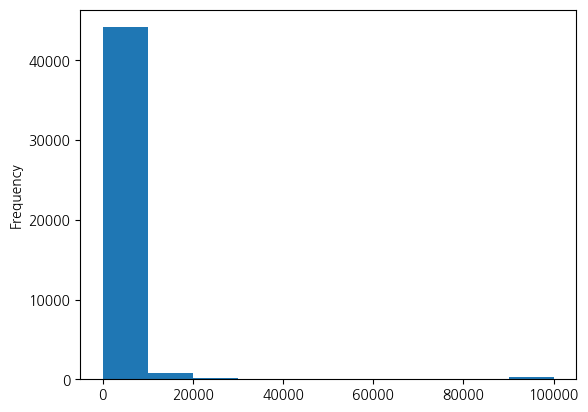

In [198]:
data['capital-gain'].plot(kind='hist')

이상값이 없음

# EDA

In [199]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45222 entries, 0 to 45221
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             45222 non-null  int64 
 1   workclass       45222 non-null  object
 2   education       45222 non-null  object
 3   education-num   45222 non-null  int64 
 4   marital-status  45222 non-null  object
 5   occupation      45222 non-null  object
 6   relationship    45222 non-null  object
 7   race            45222 non-null  object
 8   sex             45222 non-null  object
 9   capital-gain    45222 non-null  int64 
 10  capital-loss    45222 non-null  int64 
 11  hours-per-week  45222 non-null  int64 
 12  native-country  45222 non-null  object
 13  class           45222 non-null  int64 
dtypes: int64(6), object(8)
memory usage: 4.8+ MB


In [202]:
obj_cols = data.select_dtypes(include='object')
num_cols = data.select_dtypes(exclude='object')

In [222]:
ratio_result = data[['education', 'class']].groupby('education').mean().sort_values(by='class', ascending=False)
ratio_result[ratio_result['class'] > 0.40].index

Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education')

In [233]:
important_cols = []
for col in obj_cols:
    print("=" * 30, col, "=" * 30)
    print(col, f'nunique: {obj_cols[col].nunique()}')
    print(obj_cols[col].value_counts())
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

============================== workclass ==============================
workclass nunique: 7
workclass
Private             33307
Self-emp-not-inc     3796
Local-gov            3100
State-gov            1946
Self-emp-inc         1646
Federal-gov          1406
Without-pay            21
Name: count, dtype: int64
                     class
workclass                 
Self-emp-inc      0.554070
Federal-gov       0.390469
Local-gov         0.295161
Self-emp-not-inc  0.278978
State-gov         0.267215
Private           0.217702
Without-pay       0.095238

============================== education ==============================
education nunique: 16
education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool  

In [235]:
important_cols

[Index([' Self-emp-inc'], dtype='object', name='workclass'),
 Index([' Prof-school', ' Doctorate', ' Masters', ' Bachelors'], dtype='object', name='education'),
 Index([' Married-civ-spouse', ' Married-AF-spouse'], dtype='object', name='marital-status'),
 Index([' Exec-managerial', ' Prof-specialty'], dtype='object', name='occupation'),
 Index([' Wife', ' Husband'], dtype='object', name='relationship'),
 Index([], dtype='object', name='race'),
 Index([], dtype='object', name='sex'),
 Index([' Taiwan', ' France', ' India'], dtype='object', name='native-country')]

In [228]:
final_cols = []
for  col in important_cols:
    if len(col) > 0:
        print(col.name, len(col))
        final_cols.append(col.name)
#     print(len(col))
final_cols

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country']

# 수치형 변수들 EDA

In [232]:
num_cols.iloc[:, :-1]

,age,education-num,capital-gain,capital-loss,hours-per-week
0,25,7,0,0,40
1,38,9,0,0,50
2,28,12,0,0,40
3,44,10,7688,0,40
4,34,6,0,0,30
...,...,...,...,...,...
45217,27,12,0,0,38
45218,40,9,0,0,40
45219,58,9,0,0,40
45220,22,9,0,0,20


============================== age ==============================
age nunique: count    45222.000000
mean        38.547941
std         13.217870
min         17.000000
25%         28.000000
50%         37.000000
75%         47.000000
max         90.000000
Name: age, dtype: float64



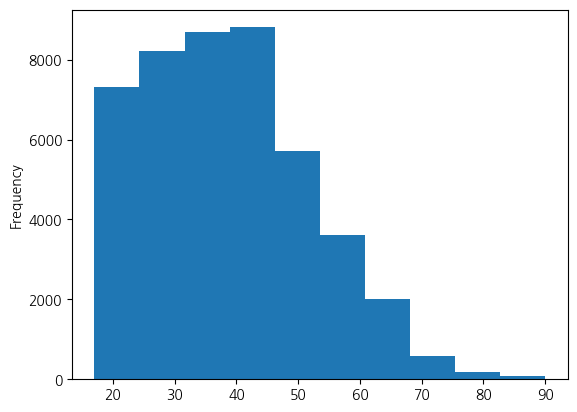


        class
age          
50   0.436671
53   0.404935
51   0.404790
54   0.404110
46   0.403955
..        ...
18   0.000000
82   0.000000
86   0.000000
87   0.000000
89   0.000000

[74 rows x 1 columns]

============================== education-num ==============================
education-num nunique: count    45222.000000
mean        10.118460
std          2.552881
min          1.000000
25%          9.000000
50%         10.000000
75%         13.000000
max         16.000000
Name: education-num, dtype: float64



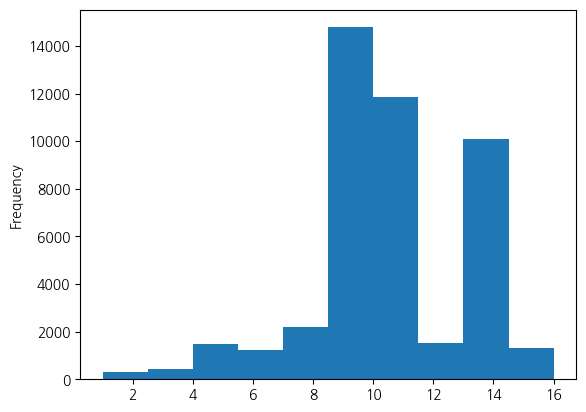


                  class
education-num          
15             0.754140
16             0.733456
14             0.554097
13             0.419815
12             0.264101
11             0.257274
10             0.201030
9              0.163431
8              0.074523
6              0.067048
4              0.066829
5              0.056213
7              0.054972
3              0.048998
2              0.036036
1              0.013889

============================== capital-gain ==============================
capital-gain nunique: count    45222.000000
mean      1101.430344
std       7506.430084
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max      99999.000000
Name: capital-gain, dtype: float64



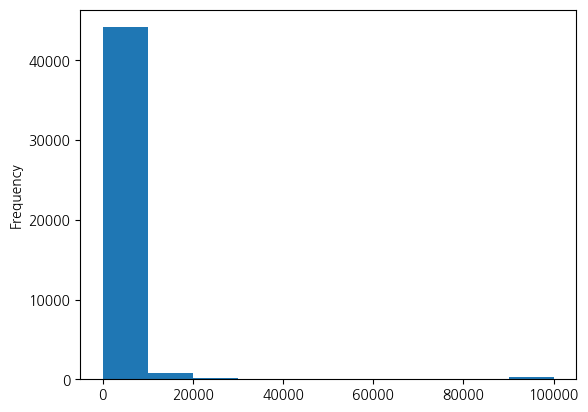


              class
capital-gain       
7298            1.0
10605           1.0
15831           1.0
15024           1.0
15020           1.0
...             ...
7443            0.0
6849            0.0
22040           0.0
34095           0.0
41310           0.0

[121 rows x 1 columns]

============================== capital-loss ==============================
capital-loss nunique: count    45222.000000
mean        88.595418
std        404.956092
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max       4356.000000
Name: capital-loss, dtype: float64



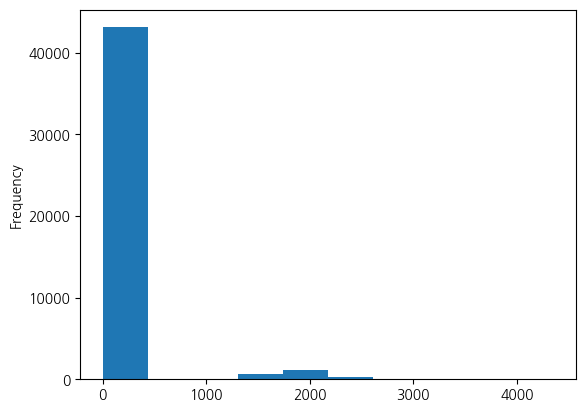


              class
capital-loss       
1564            1.0
2174            1.0
2201            1.0
2231            1.0
2246            1.0
...             ...
2754            0.0
3175            0.0
3770            0.0
3900            0.0
4356            0.0

[97 rows x 1 columns]

============================== hours-per-week ==============================
hours-per-week nunique: count    45222.000000
mean        40.938017
std         12.007508
min          1.000000
25%         40.000000
50%         40.000000
75%         45.000000
max         99.000000
Name: hours-per-week, dtype: float64



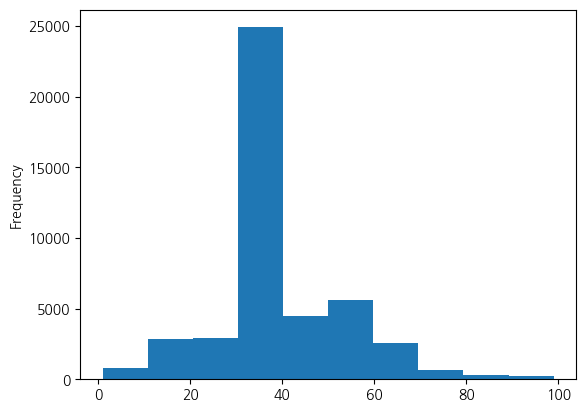


                   class
hours-per-week          
69              1.000000
61              0.750000
76              0.750000
74              0.666667
89              0.666667
...                  ...
82              0.000000
87              0.000000
88              0.000000
94              0.000000
91              0.000000

[96 rows x 1 columns]



In [236]:
for col in num_cols.iloc[:, :-1]:
    print("=" * 30, col, "=" * 30)
    print(col, f'nunique: {num_cols[col].describe()}')
    print()
    num_cols[col].plot(kind='hist')
    plt.show()
    print()
    print(data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False))
    ratio_result = data[[col, 'class']].groupby(col).mean().sort_values(by='class', ascending=False)
    important_cols.append(ratio_result[ratio_result['class'] > 0.40].index)
    print()

In [237]:
final_cols = []
for  col in important_cols:
    if len(col) > 0:
        print(col.name, len(col))
        final_cols.append(col.name)
#     print(len(col))
final_cols

workclass 1
education 4
marital-status 2
occupation 2
relationship 2
native-country 3
age 6
education-num 4
capital-gain 33
capital-loss 26
hours-per-week 16


['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'native-country',
 'age',
 'education-num',
 'capital-gain',
 'capital-loss',
 'hours-per-week']

In [240]:
data['education'].value_counts()

education
HS-grad         14783
Some-college     9899
Bachelors        7570
Masters          2514
Assoc-voc        1959
11th             1619
Assoc-acdm       1507
10th             1223
7th-8th           823
Prof-school       785
9th               676
12th              577
Doctorate         544
5th-6th           449
1st-4th           222
Preschool          72
Name: count, dtype: int64

In [241]:
data['education-num'].value_counts()

education-num
9     14783
10     9899
13     7570
14     2514
11     1959
7      1619
12     1507
6      1223
4       823
15      785
5       676
8       577
16      544
3       449
2       222
1        72
Name: count, dtype: int64

In [243]:
data_set1 = data[final_cols]
data_set1 = data_set1.drop("education", axis=1)
data_set1

,workclass,marital-status,occupation,relationship,native-country,age,education-num,capital-gain,capital-loss,hours-per-week
0,Private,Never-married,Machine-op-inspct,Own-child,United-States,25,7,0,0,40
1,Private,Married-civ-spouse,Farming-fishing,Husband,United-States,38,9,0,0,50
2,Local-gov,Married-civ-spouse,Protective-serv,Husband,United-States,28,12,0,0,40
3,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,44,10,7688,0,40
4,Private,Never-married,Other-service,Not-in-family,United-States,34,6,0,0,30
...,...,...,...,...,...,...,...,...,...,...
45217,Private,Married-civ-spouse,Tech-support,Wife,United-States,27,12,0,0,38
45218,Private,Married-civ-spouse,Machine-op-inspct,Husband,United-States,40,9,0,0,40
45219,Private,Widowed,Adm-clerical,Unmarried,United-States,58,9,0,0,40
45220,Private,Never-married,Adm-clerical,Own-child,United-States,22,9,0,0,20


In [245]:
X = pd.get_dummies(data_set1, drop_first=True)

In [246]:
X

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
0,25,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,9,0,0,50,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,12,0,0,40,True,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,10,7688,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
4,34,6,0,0,30,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45217,27,12,0,0,38,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45218,40,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45219,58,9,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
45220,22,9,0,0,20,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [247]:
y = data['class']
y

0        0
1        0
2        1
3        1
4        0
        ..
45217    0
45218    1
45219    0
45220    0
45221    1
Name: class, Length: 45222, dtype: int64

In [248]:
from sklearn.model_selection import train_test_split

In [253]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.4, stratify=y,  random_state=10)

In [254]:
X_train

,age,education-num,capital-gain,capital-loss,hours-per-week,workclass_ Local-gov,workclass_ Private,workclass_ Self-emp-inc,workclass_ Self-emp-not-inc,workclass_ State-gov,...,native-country_ Portugal,native-country_ Puerto-Rico,native-country_ Scotland,native-country_ South,native-country_ Taiwan,native-country_ Thailand,native-country_ Trinadad&Tobago,native-country_ United-States,native-country_ Vietnam,native-country_ Yugoslavia
1476,43,11,0,0,60,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
34419,41,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
35870,33,7,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
42980,52,9,0,0,45,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
40581,46,13,0,0,55,False,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5283,29,13,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1571,45,11,0,0,40,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
33856,50,13,0,0,40,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
76,43,9,0,0,44,False,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [255]:
y_train

1476     0
34419    0
35870    0
42980    0
40581    0
        ..
5283     0
1571     0
33856    0
76       0
23680    1
Name: class, Length: 27133, dtype: int64

In [256]:
y_train.value_counts()

class
0    20408
1     6725
Name: count, dtype: int64

In [257]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

In [259]:
dtc = DecisionTreeClassifier(random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.819669412350047
              precision    recall  f1-score   support

           0       0.87      0.89      0.88     13606
           1       0.64      0.61      0.63      4483

    accuracy                           0.82     18089
   macro avg       0.76      0.75      0.75     18089
weighted avg       0.82      0.82      0.82     18089



# 모델 성능 튜닝 (하이퍼파라미터 튜닝)

In [262]:
for i in range(1, 11):
    dtc = DecisionTreeClassifier(max_depth=i, random_state=10)
    dtc.fit(X_train, y_train)
    pred = dtc.predict(X_test)
    print("="*30, f"max_depth: {i}", "="*30)
    print(accuracy_score(y_test, pred))
    print(classification_report(y_test, pred))
    print()

============================== max_depth: 1 ==============================
0.7521698269666648
              precision    recall  f1-score   support

           0       0.75      1.00      0.86     13606
           1       0.00      0.00      0.00      4483

    accuracy                           0.75     18089
   macro avg       0.38      0.50      0.43     18089
weighted avg       0.57      0.75      0.65     18089


============================== max_depth: 2 ==============================
0.8239814251755211
              precision    recall  f1-score   support

           0       0.84      0.94      0.89     13606
           1       0.72      0.47      0.57      4483

    accuracy                           0.82     18089
   macro avg       0.78      0.70      0.73     18089
weighted avg       0.81      0.82      0.81     18089


============================== max_depth: 3 ==============================
0.8384653656918569
              precision    recall  f1-score   support

       

C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Admin\miniforge3\envs\fintech\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result)

============================== max_depth: 5 ==============================
0.8440488694786887
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     13606
           1       0.79      0.51      0.62      4483

    accuracy                           0.84     18089
   macro avg       0.82      0.73      0.76     18089
weighted avg       0.84      0.84      0.83     18089


============================== max_depth: 6 ==============================
0.8475869312842059
              precision    recall  f1-score   support

           0       0.86      0.95      0.90     13606
           1       0.78      0.53      0.63      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.74      0.77     18089
weighted avg       0.84      0.85      0.84     18089


============================== max_depth: 7 ==============================
0.8498535021283653
              precision    recall  f1-score   support

       

In [264]:
dtc = DecisionTreeClassifier(max_depth=9, random_state=10)
dtc.fit(X_train, y_train)
pred = dtc.predict(X_test)
print(accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

0.8526728951296368
              precision    recall  f1-score   support

           0       0.87      0.94      0.91     13606
           1       0.76      0.59      0.67      4483

    accuracy                           0.85     18089
   macro avg       0.82      0.77      0.79     18089
weighted avg       0.85      0.85      0.85     18089



# 의사결정나무 시각화

In [265]:
from sklearn.tree import plot_tree

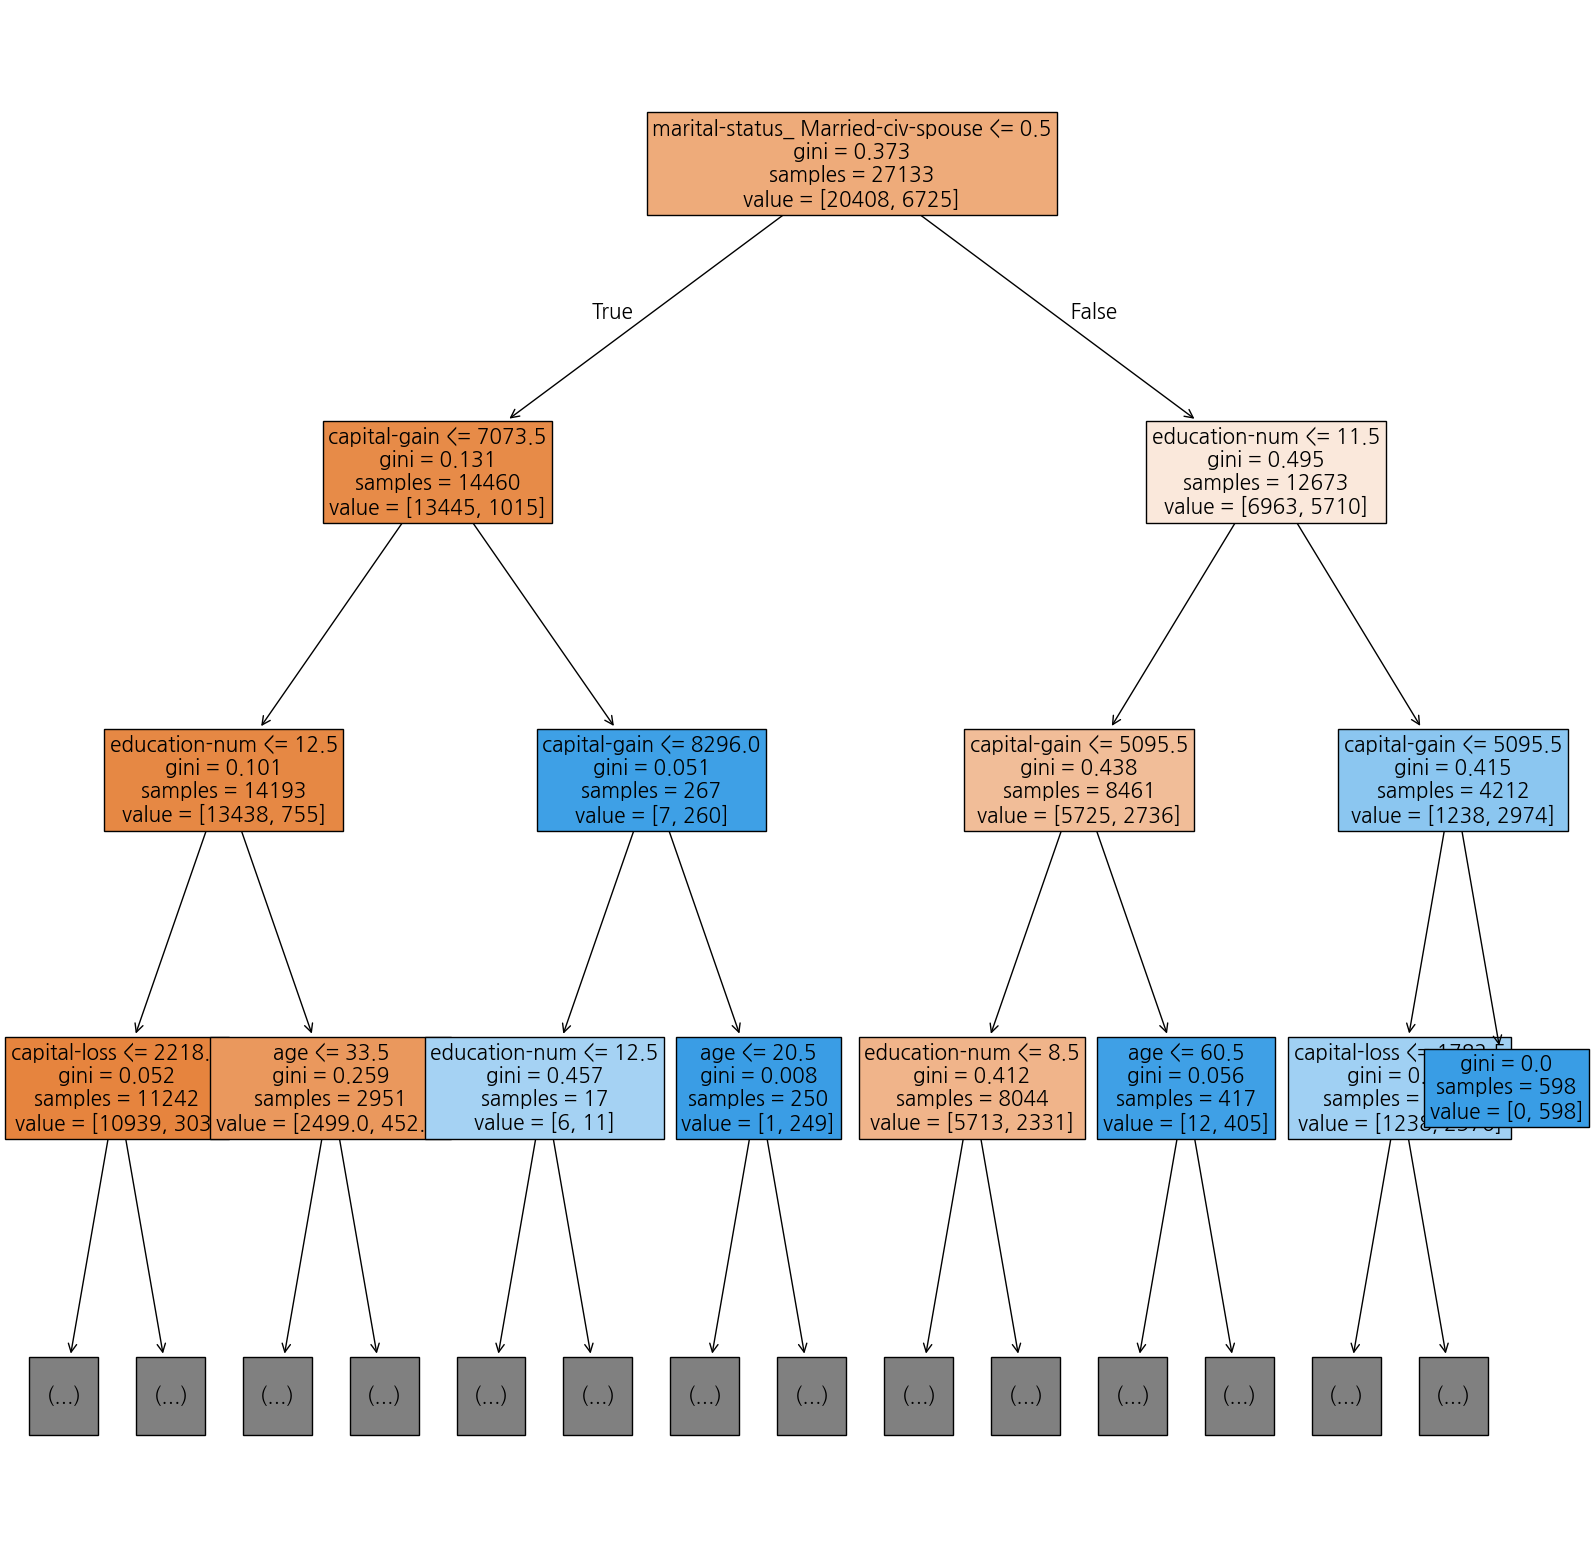

In [268]:
plt.figure(figsize=(20,20))
plot_tree(dtc, feature_names=dtc.feature_names_in_, max_depth=3, fontsize=15, filled=True)
plt.show()